# Olist E-Commerce Analysis
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Sklearn, XGBoost

**Goal:** Analyze Brazilian e-commerce data to find revenue patterns, 
customer behavior, and delivery performance insights.

**Dataset:** Olist Brazilian E-Commerce (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,confusion_matrix,classification_report,accuracy_score


In [2]:
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
orders    = pd.read_csv("dataset/olist_orders_dataset.csv")
items     = pd.read_csv("dataset/olist_order_items_dataset.csv")
products  = pd.read_csv("dataset/olist_products_dataset.csv")
payments  = pd.read_csv("dataset/olist_order_payments_dataset.csv")

## Cleaning Dataset

`customers`

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [5]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

In [7]:
customers.duplicated().sum()

0

`Orders`

In [8]:
orders.shape

(99441, 8)

In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [11]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [12]:
orders.duplicated().sum()

0

In [13]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

`Handling Missing values`

In [14]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

We found missing values in order_approved_at, 
order_delivered_carrier_date, and order_delivered_customer_date. After checking the order_status column, 
we found that most missing values belonged to orders that were canceled, unavailable, processing, invoiced, 
or still shipped. Since these orders were not completed, the missing dates were expected. 
Therefore, we kept these missing values instead of filling or deleting them. 

Only a few delivered orders had missing delivery dates, which were considered data inconsistencies and we remove them.

`Remove those 8 raws of data inconsistency`

In [16]:
inconsistent_rows = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
)
orders = orders[~inconsistent_rows]

In [17]:
orders.shape

(99433, 8)

#### Convert Date Columns To DateTime

In [18]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col]=pd.to_datetime(orders[col])

In [19]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

### Feature Engineering


In [20]:
orders["delivery_days"]=(orders["order_delivered_customer_date"]-orders["order_purchase_timestamp"]).dt.days

In [21]:
orders.loc[orders["order_status"]=="delivered",["order_status","delivery_days"]].head(10)

,order_status,delivery_days
0,delivered,8.0
1,delivered,13.0
2,delivered,9.0
3,delivered,13.0
4,delivered,2.0
5,delivered,16.0
7,delivered,9.0
8,delivered,9.0
9,delivered,18.0
10,delivered,12.0


`Minimum Delivery time`

In [22]:
orders["delivery_days"].min()

0.0

`Maximum delivery time`

In [23]:
orders["delivery_days"].max()

209.0

`Most comman delivery Time`

In [24]:
orders["delivery_days"].mode()

0    7.0
Name: delivery_days, dtype: float64

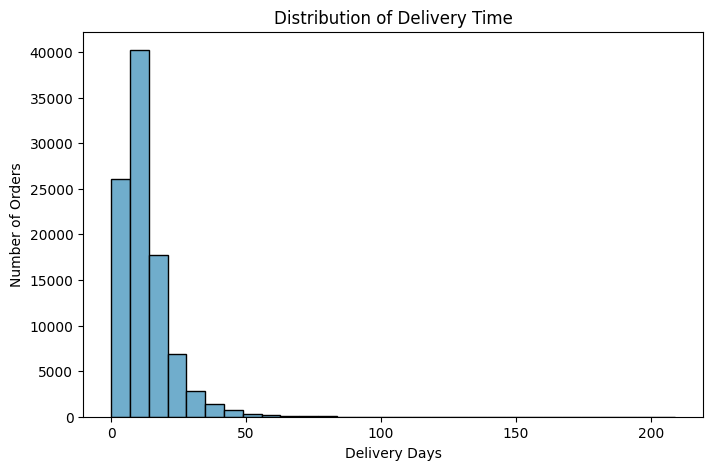

In [25]:
plt.figure(figsize=(8,5))
plt.hist(orders["delivery_days"].dropna(), bins=30, edgecolor='black',color="#70ADCC")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")
plt.show()

`Items`

In [26]:
items.shape

(112650, 7)

In [27]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [28]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [29]:
items["shipping_limit_date"]=pd.to_datetime(items["shipping_limit_date"])

In [30]:
items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

In [31]:
items.duplicated().sum()

0

In [32]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

`Products`

In [33]:
products.shape

(32951, 9)

In [34]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [35]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


### Feature engineering

In [36]:
products["product_volume"] = (
    products["product_length_cm"]
    * products["product_height_cm"]
    * products["product_width_cm"]
)
products["product_volume"].value_counts().head()

product_volume
8000.0     604
352.0      588
4096.0     419
2560.0     327
27000.0    327
Name: count, dtype: int64

In [37]:
products["weight_category"]=pd.cut(products["product_weight_g"],
                                   bins=[0,500,2000,100000],
                                   labels=["light","medium","heavy"])

In [38]:
products.drop(
    columns=[
        "product_name_lenght",
        "product_description_lenght"
    ],
    inplace=True
)

`Payments`

In [39]:
payments.shape

(103886, 5)

In [40]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [41]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [42]:
payments.duplicated().sum()

0

In [43]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

### Feature engineering

In [44]:
payments["payment_mode"]=np.where(payments["payment_installments"]==1,
                                  "Single Payment",
                                  "EMI")
payments["payment_mode"].value_counts().head()

payment_mode
Single Payment    52546
EMI               51340
Name: count, dtype: int64

### Merge All Datasets

In [45]:
df=orders.merge(customers,on="customer_id",how="left")

In [46]:
df.shape

(99433, 13)

In [47]:
df=df.merge(items,on="order_id",how="left")

In [48]:
df.shape

(113417, 19)

In [49]:
df=df.merge(products,on="product_id",how="left")

In [50]:
df.shape

(113417, 27)

In [51]:
df=df.merge(payments,on="order_id",how="left")

In [52]:
df.shape

(118426, 32)

## **EDA**

In [53]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_volume', 'weight_category', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'payment_mode'],
      dtype='str')

## Sales Performance

### Which State generate the most revenue.

In [54]:
city_price=df.groupby("customer_state")["price"].sum().sort_values(ascending=False)
city_price

customer_state
SP    5447231.54
RJ    1913564.16
MG    1639636.83
RS     787591.53
PR     705856.47
BA     541411.20
SC     538215.45
DF     313068.06
GO     309834.22
ES     283897.93
PE     271258.36
CE     239418.24
PA     184407.88
MT     170822.04
PB     123726.34
MA     122881.79
MS     119823.41
RN      94554.55
PI      92167.70
AL      83110.36
SE      60954.60
TO      56251.91
RO      46964.03
AM      22809.36
AC      17059.44
AP      13654.30
RR       7829.43
Name: price, dtype: float64

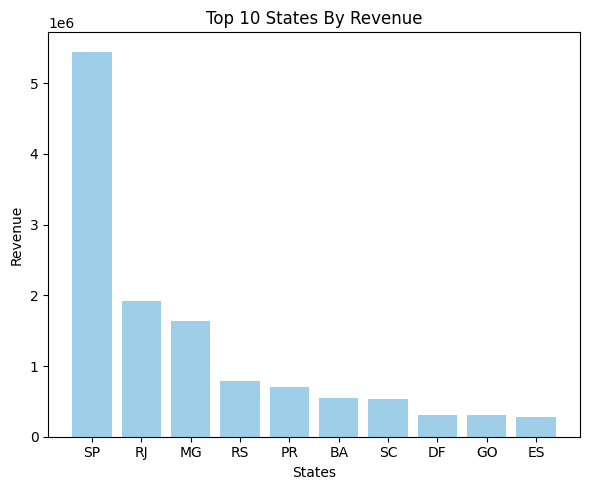

In [55]:
top_states=city_price.head(10)
plt.figure(figsize=(6,5))
plt.bar(top_states.index,top_states.values,color="#9FCFE8")
plt.title("Top 10 States By Revenue")
plt.xlabel("States")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

`São Paulo generated the highest revenue among all states.`
Indicating a large customer base and purchasing activity compared to other regions.

`Insight: `São Paulo city has the highest number of customers
confirming it as the most active e-commerce region in Brazil.

`Business Recommendation:`
→ Focus marketing campaigns in top 5 cities
→ Open fulfillment centers near top cities
   to reduce delivery time and freight costs

### Which Month Have The Highest sales?


In [56]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
# Add this BEFORE the pd.Categorical line
df["purchase_month"] = df["order_purchase_timestamp"].dt.month_name()
df["purchase_month"] = pd.Categorical(df["purchase_month"], categories=month_order, ordered=True)

month_sales=df.groupby("purchase_month")["price"].sum()
month_sales

purchase_month
January      1115789.40
February     1140853.65
March        1422387.10
April        1421256.72
May          1577312.09
June         1361766.62
July         1458452.31
August       1486067.07
September     662688.75
October       744749.83
November     1046010.54
December      770667.05
Name: price, dtype: float64

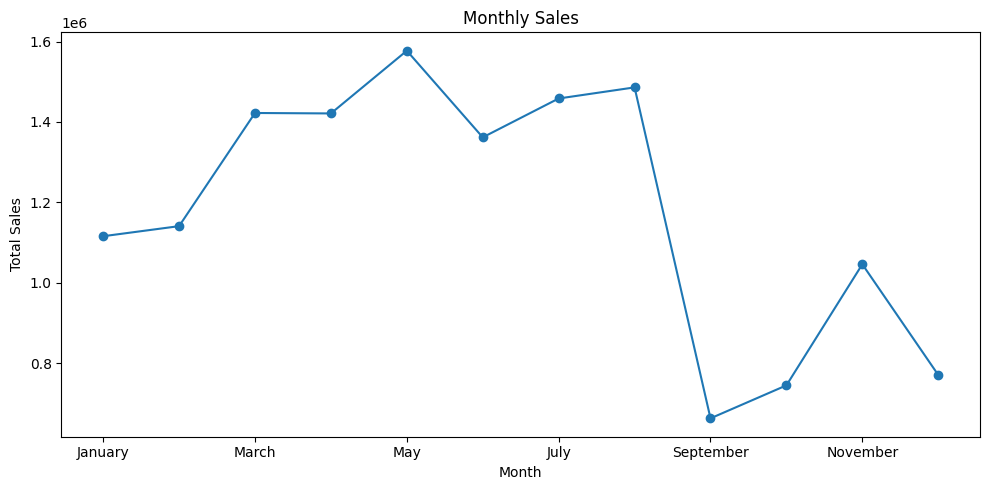

In [57]:
month_sales.plot(kind="line", figsize=(10,5), marker="o", title="Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

`Insight:Sales are highest from March to August 
peaking in May.`

### Which product categories generate the most revenue?

In [58]:
cat_sales=df.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10)
cat_sales

product_category_name
beleza_saude              1297490.77
relogios_presentes        1252865.30
cama_mesa_banho           1092551.02
esporte_lazer             1023817.34
informatica_acessorios     942166.58
moveis_decoracao           765093.89
utilidades_domesticas      666587.00
cool_stuff                 662309.49
automotivo                 616635.21
ferramentas_jardim         518217.54
Name: price, dtype: float64

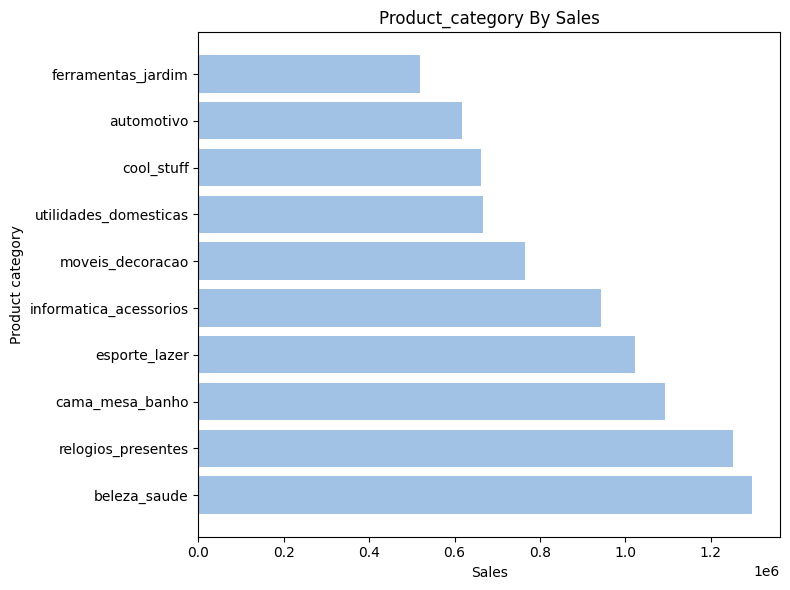

In [59]:
plt.figure(figsize=(8,6))
plt.barh(cat_sales.index,cat_sales.values,color="#A1C2E5")
plt.title("Product_category By Sales")
plt.xlabel("Sales")
plt.ylabel("Product category")
plt.tight_layout()
plt.show()

`Insight: bed_bath_table and health_beauty are top revenue 
generating categories indicating strong home and personal 
care demand.`

### How long do deliveries do?
 `"On average, how many days does delivery take in each state?"`

In [60]:
df["delivery_days"].describe()

count    115037.000000
mean         12.019237
std           9.461440
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [61]:
state_delivery = df.groupby("customer_state")["delivery_days"].mean().sort_values()
state_delivery

customer_state
SP     8.270919
MG    11.497541
PR    11.516530
DF    12.468815
SC    14.498461
RS    14.693200
RJ    14.763646
GO    14.928752
MS    15.051497
ES    15.226268
TO    16.664671
MT    17.526413
PE    17.794311
BA    18.721628
PI    18.896926
RN    19.197861
RO    19.234875
PB    20.126806
AC    20.170213
CE    20.354903
SE    20.886010
MA    21.255501
PA    23.255963
AL    24.138322
AM    26.100592
AP    27.662651
RR    27.826087
Name: delivery_days, dtype: float64

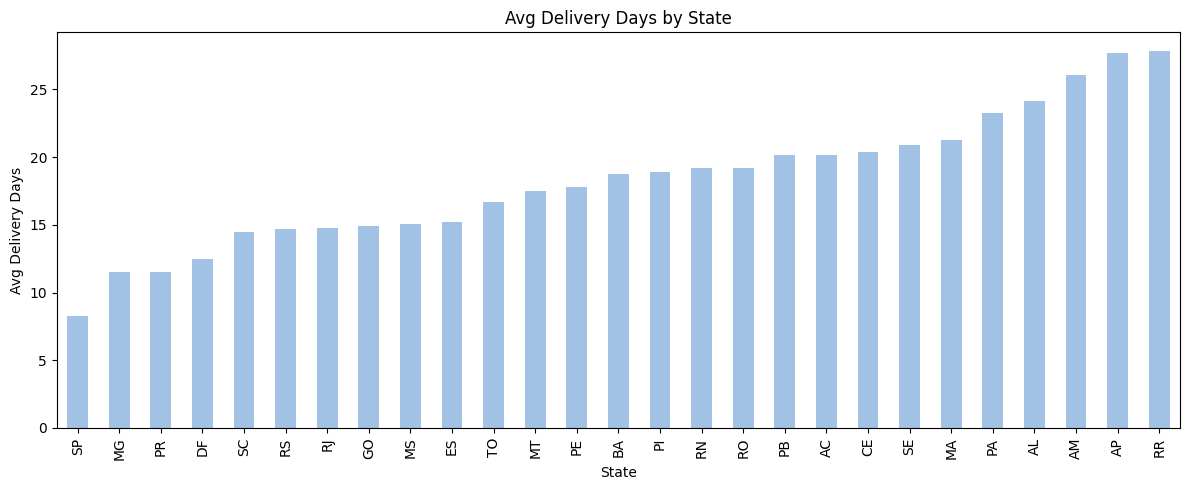

In [62]:
state_delivery.plot(kind="bar", figsize=(12,5), title="Avg Delivery Days by State",color="#A1C2E5")
plt.xlabel("State")
plt.ylabel("Avg Delivery Days")
plt.tight_layout()
plt.show()

`Insight:` Delivery time varies significantly across states.
Remote states take 25+ days while São Paulo delivers 
within 8-10 days showing strong logistics inequality.

`Business Recommendation:`
→ Partner with local couriers in remote states
→ Set realistic delivery estimates to reduce complaints
→ Offer faster shipping options in high revenue states.

 ### Which Payment method do customers prefer.

In [63]:
df["payment_type"].value_counts()


payment_type
credit_card    87279
boleto         23037
voucher         6407
debit_card      1697
not_defined        3
Name: count, dtype: int64

<Axes: title={'center': 'Payment Method Preference'}>

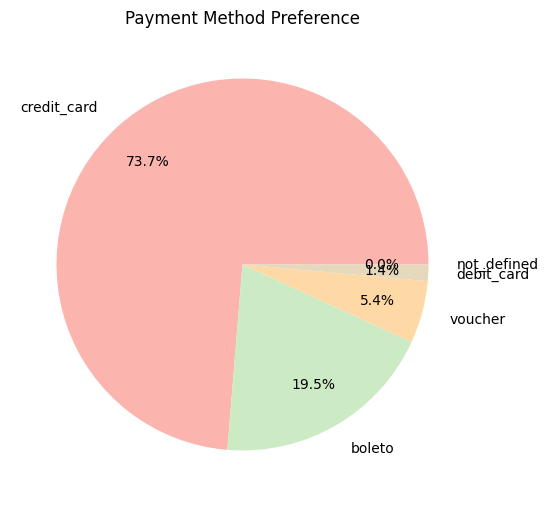

In [64]:
df["payment_type"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,7), 
                                        colormap="Pastel1", pctdistance=0.75, labeldistance=1.15,title="Payment Method Preference")

`Insight: 73% customers prefer credit card showing strong 
digital payment adoption.`

In [65]:
df["payment_mode"].value_counts()

payment_mode
EMI               59309
Single Payment    59114
Name: count, dtype: int64

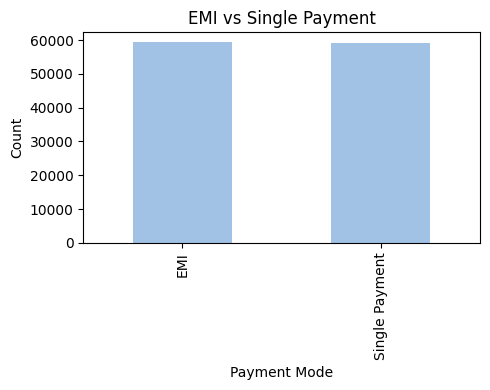

In [66]:
df["payment_mode"].value_counts().plot(kind="bar", figsize=(5,4), title="EMI vs Single Payment",color="#A1C2E5")
plt.xlabel("Payment Mode")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

`Insight:` EMI and Single Payment are almost equal
showing customers prefer flexibility in payment options.

`Business Recommendation:`
→ Offer more EMI options to encourage 
   higher value purchases
→ Provide discounts on single payment 
   to reduce payment processing costs

 ### How much do customers pay for shipping?

In [67]:
df["freight_value"].describe()

count    117596.000000
mean         20.045812
std          15.861805
min           0.000000
25%          13.080000
50%          16.290000
75%          21.190000
max         409.680000
Name: freight_value, dtype: float64

In [68]:
df.groupby("customer_state")["freight_value"].mean().sort_values(ascending=False)

customer_state
PB    43.257778
RR    42.984423
RO    40.970175
AC    40.021684
TO    39.677286
PI    39.233229
MA    38.258685
SE    36.627935
AL    35.739410
PA    35.735708
RN    35.279930
AP    34.084405
AM    33.079181
PE    32.781133
CE    32.463275
MT    28.970951
BA    26.318829
MS    23.415706
GO    22.731494
ES    21.981424
RS    21.829559
SC    21.435695
RJ    21.100930
DF    21.075148
MG    20.626288
PR    20.575258
SP    15.198033
Name: freight_value, dtype: float64

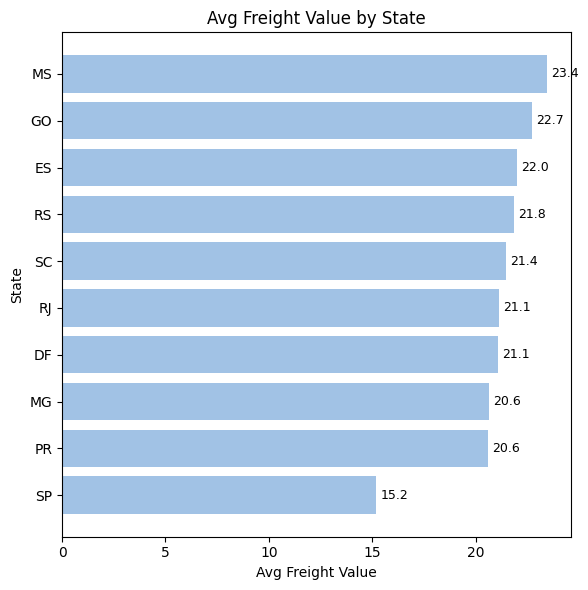

In [69]:
state_freight = df.groupby("customer_state")["freight_value"].mean().sort_values().head(10)


plt.figure(figsize=(6,6))
plt.barh(state_freight.index, state_freight.values, color="#A1C2E5")
plt.title("Avg Freight Value by State")
plt.xlabel("Avg Freight Value")
plt.ylabel("State")
for i,val in enumerate(state_freight.values):
    plt.text(val + 0.2, i, f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

`Insight: States farther from São Paulo pay higher 
freight costs due to longer distances.`

#### Customer Geography

In [70]:
df["customer_city"].value_counts().head(10)


customer_city
sao paulo                18738
rio de janeiro            8252
belo horizonte            3272
brasilia                  2473
curitiba                  1820
campinas                  1750
porto alegre              1661
salvador                  1534
guarulhos                 1411
sao bernardo do campo     1122
Name: count, dtype: int64

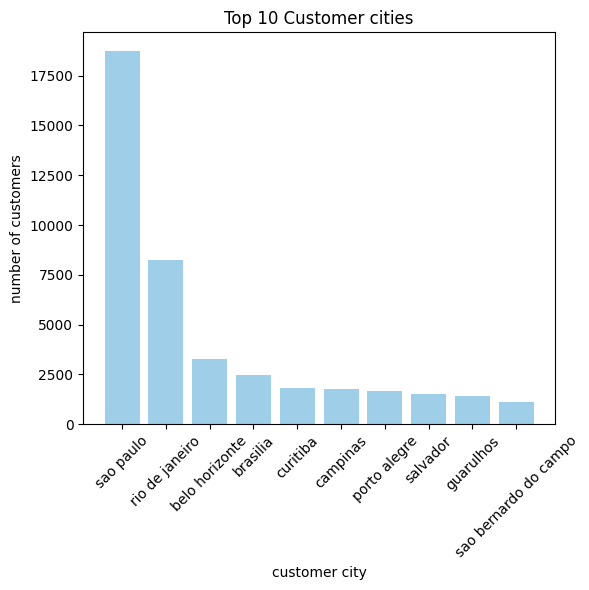

In [71]:
cus_geo=df["customer_city"].value_counts().head(10)
plt.figure(figsize=(6,6))
plt.bar(cus_geo.index,cus_geo.values,color="#9FCFE8")
plt.title("Top 10 Customer cities")
plt.xlabel("customer city")
plt.ylabel("number of customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### How much revenue is at risk because of late deliveries.

In [72]:
df["is_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
df["is_late"].value_counts()

is_late
0    109399
1      9027
Name: count, dtype: int64

In [73]:
Late_orders=df[df["is_late"]==1]
revenue_lost=Late_orders["price"].sum()
total_revenue=df["price"].sum()
late_percentage = (revenue_lost / total_revenue) * 100

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Revenue at Risk (Late Orders): R$ {revenue_lost:,.2f}")
print(f"Percentage of Revenue at Risk: {late_percentage:.2f}%")






Total Revenue: R$ 14,208,001.13
Revenue at Risk (Late Orders): R$ 1,206,794.19
Percentage of Revenue at Risk: 8.49%


Total Revenue: R$ 14,208,001.13

Revenue at Risk (Late Orders): R$ 1,206,794.19

`Percentage of Revenue at Risk: 8.49%`

## "Can we predict how many days delivery will take based on product and shipping details?"

In [74]:
ml_df=df[["freight_value", "price", "product_weight_g", "delivery_days"]].dropna()
ml_df.shape

(115017, 4)

In [75]:
x = ml_df[["freight_value", "price", "product_weight_g"]]  
y = ml_df["delivery_days"] 

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("MAE:",round(mean_absolute_error(y_test,y_pred),2))
print('R2Score:',round(r2_score(y_test,y_pred),2))

MAE: 6.13
R2Score: 0.05


Insight: Linear Regression achieved R2 of 0.05 which is low.

This is because delivery days depends heavily on geographic 
distance between seller and customer which was not available 
in our dataset. 

Adding seller location and distance features would likely improve model performance significant.

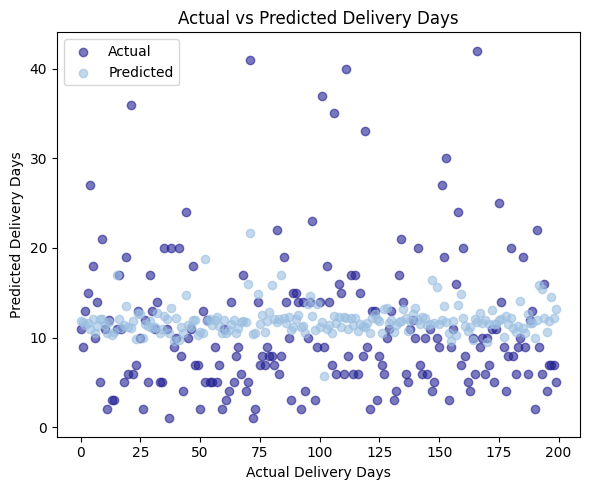

In [77]:
plt.figure(figsize=(6,5))
plt.scatter(range(200), y_test[:200], alpha=0.6, color="#222092", label="Actual")
plt.scatter(range(200), y_pred[:200], alpha=0.6, color="#9BBFE1", label="Predicted")
plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title("Actual vs Predicted Delivery Days")
plt.legend()
plt.tight_layout()
plt.show()

`Model is predicting average for all orders showing that freight_value, 
price and product_weight alone are not sufficient to predict delivery days accurately.

Geographic distance between seller and customer would be a 
much stronger predictor.`

## "Based on product and shipping details — will this order be delivered late?"

In [78]:
df["is_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
df["is_late"].value_counts()

is_late
0    109399
1      9027
Name: count, dtype: int64

`On time = 109,399 orders  (92%)`

`Late    =   9,027 orders  (8%)`

In [79]:
log_df = df[["freight_value", "price", "product_weight_g", "delivery_days", "is_late"]].dropna()

x = log_df[["freight_value", "price", "product_weight_g", "delivery_days"]]
y = log_df["is_late"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


### With LogisticRegression

In [80]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
log_model=LogisticRegression()
log_model.fit(x_train, y_train)
y_pred = log_model.predict(x_test)
print(classification_report(y_test, y_pred))
print("\n Accuracy score:",accuracy_score(y_test,y_pred))
print("\nconfusion_matrix:",confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     21159
           1       0.81      0.51      0.63      1845

    accuracy                           0.95     23004
   macro avg       0.89      0.75      0.80     23004
weighted avg       0.95      0.95      0.95     23004


 Accuracy score: 0.9515301686663189

confusion_matrix: [[20944   215]
 [  900   945]]


`
Insight: Logistic Regression achieved 95% accuracy but 
recall for late orders is only 51% meaning it misses 
half of actual late deliveries. This is due to class 
imbalance — 92% orders are on time. `

XGBoost will be used next to improve late order detection.


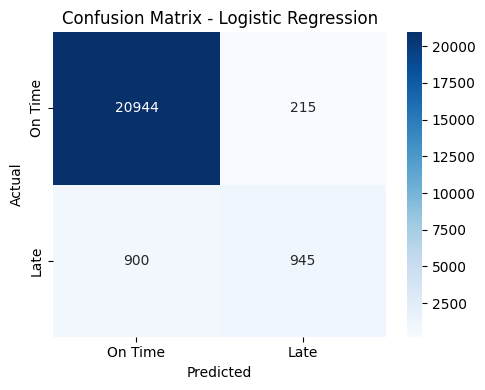

In [81]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["On Time","Late"],
            yticklabels=["On Time","Late"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### With XGBOOST

In [82]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(x_train, y_train)

# Step 2 - Predict
y_pred_xgb = xgb_model.predict(x_test)

# Step 3 - Evaluate
print(classification_report(y_test, y_pred_xgb))
print("\naccuracy_score:",accuracy_score(y_test,y_pred_xgb))
print("\nconfusion_matrix:",confusion_matrix(y_test,y_pred_xgb))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21159
           1       0.79      0.62      0.70      1845

    accuracy                           0.96     23004
   macro avg       0.88      0.80      0.84     23004
weighted avg       0.95      0.96      0.95     23004


accuracy_score: 0.9566597113545471

confusion_matrix: [[20857   302]
 [  695  1150]]


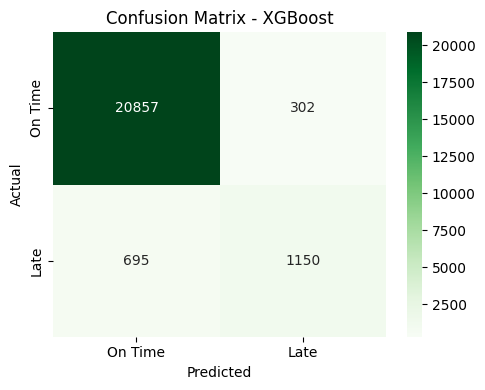

In [83]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["On Time","Late"],
            yticklabels=["On Time","Late"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

`Insight: XGBoost improved late delivery detection from 
51% to 62% recall compared to Logistic Regression. 
This means XGBoost catches more actual late deliveries 
making it a better model for this business problem.`


## Model Summary


**Linear Regression** — Predicted delivery days but got R2 = 0.05.
Low score because distance between seller and customer was missing from data.

**Logistic Regression** — Predicted late deliveries with 95% accuracy
but missed 49% of actual late orders due to imbalanced data.

**XGBoost** — Improved late delivery detection to 62% recall,
performing better than Logistic Regression on imbalanced data.
Geographic distance between seller and customer 
would further improve all models.


In [84]:
df.to_csv("olist_final.csv", index=False)

In [85]:
import os
os.getcwd()

'c:\\Users\\Tanuja\\OneDrive\\Documents\\retail_project'

## RFM

In [86]:
df[["customer_unique_id", "order_purchase_timestamp", "order_id", "price"]].head()

,customer_unique_id,order_purchase_timestamp,order_id,price
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,29.99
1,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,29.99
2,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,29.99
3,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,118.70
4,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,159.90


In [87]:
from datetime import timedelta
#Reference Date
reference_date=df["order_purchase_timestamp"].max()+timedelta(days=1)
#calculate RFM
rfm=df.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp",lambda x:(reference_date-x.max()).days),
    Frequency=("order_id","nunique"),
    Monetary=("price","sum")        
).reset_index()
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00


In [88]:
rfm.describe()

,Recency,Frequency,Monetary
count,96088.000000,96088.000000,96088.000000
mean,288.743881,1.034812,147.864469
std,153.413204,0.214392,248.029658
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,47.900000
50%,269.000000,1.000000,89.900000
75%,398.000000,1.000000,159.800000
max,773.000000,17.000000,13440.000000


In [89]:
rfm["Frequency"].value_counts()


Frequency
1     93091
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

`Nearly 97% of customers purchased only once.`

This means:

Customer retention is very low.
Most customers never return.
The business heavily depends on acquiring new customers.

In [90]:
rfm["Monetary"].describe()


count    96088.000000
mean       147.864469
std        248.029658
min          0.000000
25%         47.900000
50%         89.900000
75%        159.800000
max      13440.000000
Name: Monetary, dtype: float64

Mean is much larger.

This tells us:

`👉 A few customers spend extremely high amounts.`

Business Insight

Revenue is concentrated among a small group of customers.

These customers should be identified and protected.

In [91]:
rfm[rfm["Monetary"]==0]

,customer_unique_id,Recency,Frequency,Monetary
123,004ad212c650c96c8a48f30855a7bcb8,389,1,0.0
177,0071f46a072a9ae25bbe4438b15efe9c,624,1,0.0
238,009b0127b727ab0ba422f6d9604487c7,765,1,0.0
372,00f0b70fdcb8a6e1671b52a2472bd41f,743,1,0.0
475,013b083525868a0437652ebf071cda03,319,1,0.0
...,...,...,...,...
95585,feb643dc81ca576d83810f147e0e089c,591,1,0.0
95604,fec36733d170d71e390acde47d74c6d6,534,1,0.0
95746,ff222edf83338ca6b35f8e29871fa07a,427,1,0.0
95757,ff28720521c749234b1ba19c9c986f4c,610,1,0.0


It means 676 customers spend R$0.
it because of incomplete orders or cancelled /refund orders.


`Find customers whose Monetary = 0, go back to the original dataset, get all their orders, and count their order statuses.`

In [92]:
zero_customers = rfm[rfm["Monetary"]==0]["customer_unique_id"]

mask = df["customer_unique_id"].isin(zero_customers)

statuses = df[mask]["order_status"]



In [93]:
statuses.value_counts()

order_status
unavailable    608
canceled       116
created          4
invoiced         2
shipped          1
Name: count, dtype: int64

In [94]:
rfm = rfm[rfm["Monetary"] > 0]

### Create simple segmentations

In [95]:
def segment_customer(row):

    if (row["Recency"] <= 90 and
        row["Frequency"] >= 2 and
        row["Monetary"] >= 500):
        return "Champions"

    elif (row["Recency"] <= 180 and
          row["Frequency"] >= 2):
        return "Loyal Customers"

    elif row["Monetary"] >= 500:
        return "Big Spenders"

    elif (row["Recency"] > 365 and
          row["Frequency"] == 1):
        return "At Risk"

    else:
        return "Regular Customers"

In [96]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm["Segment"].value_counts()                             # count customers in each segment+

Segment
Regular Customers    64206
At Risk              26257
Big Spenders          3980
Loyal Customers        933
Champions               36
Name: count, dtype: int64

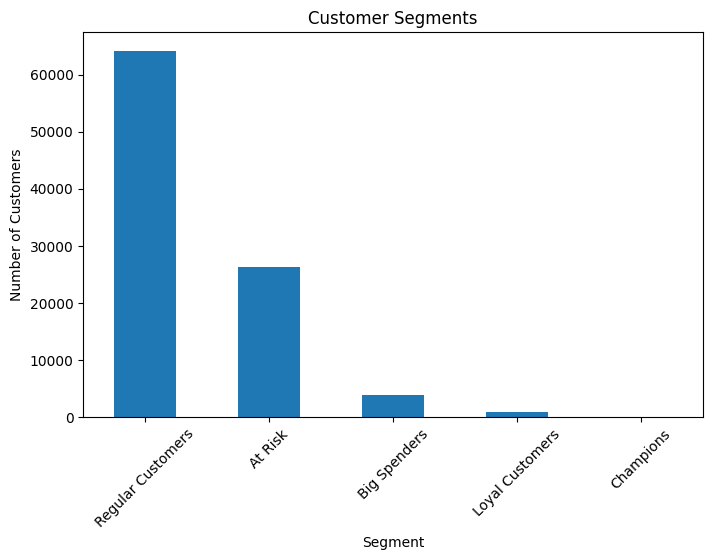

In [99]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Revenue by segments

In [100]:
rfm.groupby("Segment")["Monetary"]\
   .sum()\
   .sort_values(ascending=False)

Segment
Regular Customers    7178637.81
Big Spenders         3876868.30
At Risk              2877803.69
Loyal Customers       238841.35
Champions              35849.98
Name: Monetary, dtype: float64

### Average spendings

In [101]:
rfm.groupby("Segment")["Monetary"]\
   .mean()\
   .sort_values(ascending=False)

Segment
Champions            995.832778
Big Spenders         974.087513
Loyal Customers      255.992872
Regular Customers    111.806339
At Risk              109.601390
Name: Monetary, dtype: float64

### Average recency and frequency

In [102]:
rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,483.816658,1.000000,109.601390
Big Spenders,296.735176,1.067337,974.087513
Champions,71.833333,2.888889,995.832778
Loyal Customers,115.632369,2.125402,255.992872
Regular Customers,210.164003,1.030371,111.806339


### Recommendations

`Champions`

.Give loyalty rewards

.Early access offers

`Loyal Customers`

.Membership programs

.Personalized recommendations

`Big Spenders`

.Premium products

.Exclusive discounts

`At Risk`

.Email campaigns

.Coupons

.Re-engagement offers